In [1]:
from sklearn.naive_bayes import GaussianNB
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import (accuracy_score, precision_score,confusion_matrix, f1_score,recall_score, auc, roc_curve,ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import time
import tracemalloc

In [2]:
phishing = fetch_ucirepo(id=327)
x = phishing.data.features
y = phishing.data.targets.values.ravel()
print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 11055 samples, 30 features


In [3]:
x_trn, x_tst, y_trn, y_tst = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [4]:
scaler = joblib.load("scaler1.pkl")
x_trn = scaler.transform(x_trn)
x_tst = scaler.transform(x_tst)


In [5]:
nb = GaussianNB()
nb.fit(x_trn, y_trn)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [6]:
start = time.time()
y_pred = nb.predict(x_tst)
prediction_time = time.time() - start

tracemalloc.start()
_ = nb.predict(x_tst)
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()


In [7]:
joblib.dump(nb, "nbModel.pkl")
print("Model saved as nbModel.pkl")

Model saved as nbModel.pkl


In [8]:
train_accuracy = nb.score(x_trn, y_trn)
test_accuracy  = accuracy_score(y_tst, y_pred)

print("\n========== OVERFITTING CHECK ==========")
print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Difference        : {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Status            : No Overfitting (difference < 2%)")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("Status            : Slight Overfitting (difference 2-5%)")
else:
    print("Status            : Overfitting detected (difference > 5%)")


========== OVERFITTING CHECK ==========
Training Accuracy : 0.6042 (60.42%)
Test Accuracy     : 0.5837  (58.37%)
Difference        : 0.0205
Status            : Slight Overfitting (difference 2-5%)


In [9]:
accuracy  = accuracy_score(y_tst, y_pred)
precision = precision_score(y_tst, y_pred)
recall    = recall_score(y_tst, y_pred)
f1score   = f1_score(y_tst, y_pred)
confusionMatrix = confusion_matrix(y_tst, y_pred)
print(f"Accuracy  = {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision = {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    = {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1 Score  = {f1score:.4f}  ({f1score*100:.2f}%)")
print(f"\nPrediction Time : {prediction_time:.6f} sec")
print(f"Peak Memory     : {peak_mem / 1024:.2f} KB")

Accuracy  = 0.5837  (58.37%)
Precision = 0.9942  (99.42%)
Recall    = 0.2705  (27.05%)
F1 Score  = 0.4253  (42.53%)

Prediction Time : 0.002341 sec
Peak Memory     : 1635.31 KB


In [10]:
print(f"\nConfusion Matrix:\n{confusionMatrix}")


Confusion Matrix:
[[1425    3]
 [1378  511]]


In [11]:
y_prob = nb.predict_proba(x_tst)[:, 1]
fpr, tpr, _ = roc_curve(y_tst, y_prob)
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC Score = {roc_auc:.4f}")


ROC-AUC Score = 0.9647


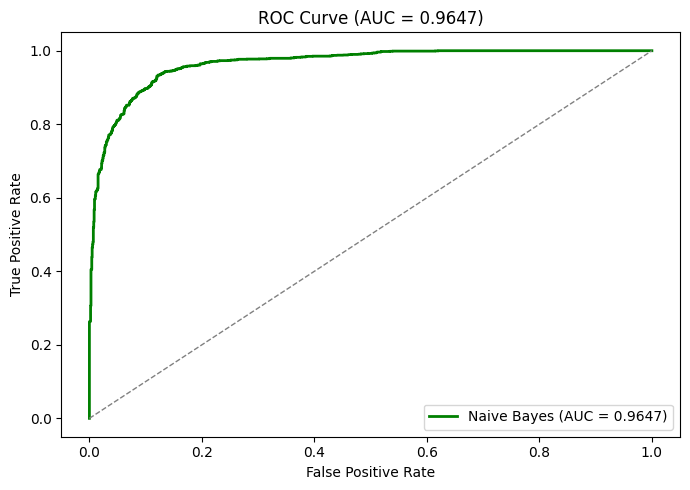

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='green', lw=2,
         label=f"Naive Bayes (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_naive_bayes.png", dpi=150)
plt.show()

In [13]:
summary = pd.DataFrame({
    "Model": ["Naive Bayes"],
    "Accuracy (%)":  [round(accuracy * 100, 2)],
    "Precision (%)": [round(precision * 100, 2)],
    "Recall (%)":    [round(recall * 100, 2)],
    "F1-Score (%)":  [round(f1score * 100, 2)],
    "ROC-AUC":       [round(roc_auc, 4)],
    "Pred Time (s)": [round(prediction_time, 6)],
    "Peak Mem (KB)": [round(peak_mem / 1024, 2)]
})

print("\n------------------------ SUMMARY TABLE -----------------------")
print(summary.to_string(index=False))


------------------------ SUMMARY TABLE -----------------------
      Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Pred Time (s)  Peak Mem (KB)
Naive Bayes         58.37          99.42       27.05         42.53   0.9647       0.002341        1635.31
